In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap
from module_16 import FlowMatchingModel

In [2]:
#### ResNet Features ####
class ResNetBottleneckExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
        self.features = []
        self.model.scalar_field.resnet_branch.avgpool.register_forward_hook(self._hook_fn)
        
    def _hook_fn(self, module, input, output):
        self.features.append(output.view(output.size(0), -1).detach().cpu())
    
    def extract_features(self, total_mass, star_maps, gas_maps, T_maps, P_maps, astro_params, batch_size=25):
        all_features = []
        n_samples = len(total_mass)
        
        for i in range(0, n_samples, batch_size):
            self.features = []
            end_idx = min(i + batch_size, n_samples)
            
            # Prepare batch tensors
            total_mass_batch = torch.FloatTensor(total_mass[i:end_idx]).unsqueeze(1).to(self.device)
            target_maps = torch.stack([
                torch.FloatTensor(star_maps[i:end_idx]),
                torch.FloatTensor(gas_maps[i:end_idx]),
                torch.FloatTensor(T_maps[i:end_idx]),
                torch.FloatTensor(P_maps[i:end_idx])
            ], dim=1).to(self.device)
            
            # Handle astro params
            astro_start = i // 15
            astro_end = min((end_idx + 14) // 15, len(astro_params))
            astro_batch = torch.FloatTensor(astro_params[astro_start:astro_end]).to(self.device)
            
            # Forward pass setup
            batch_sz = total_mass_batch.size(0)
            t = torch.rand(batch_sz, device=self.device)
            
            x0 = total_mass_batch.expand(-1, 4, -1, -1)
            x1 = target_maps
            x_t = (1 - t.view(-1, 1, 1, 1)) * x0 + t.view(-1, 1, 1, 1) * x1
            
            if astro_batch.size(0) != batch_sz:
                repeat_factor = (batch_sz + astro_batch.size(0) - 1) // astro_batch.size(0)
                astro_batch = astro_batch.repeat(repeat_factor, 1)[:batch_sz]
            
            condition_param = torch.cat([t.unsqueeze(1), astro_batch], dim=1)
            
            with torch.no_grad():
                _ = self.model.scalar_field(x_t, condition_param, total_mass_batch, target_maps)
            
            if self.features:
                all_features.append(torch.cat(self.features, dim=0).numpy())
            
            # Clear memory
            del total_mass_batch, target_maps, astro_batch, x_t, condition_param
            torch.cuda.empty_cache()
        
        return np.vstack(all_features) if all_features else np.array([])

In [6]:
def load_all_model_data_for_normalization(simulation_models, data_dir="/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"):
    """Load all model data and compute global normalization statistics"""
    
    all_total_mass_log = []
    all_star_maps_log = []
    all_gas_maps_log = []
    all_T_maps_log = []
    all_P_maps_log = []
    
    # Load and log-transform data from all models
    for model_name in simulation_models:
        print(f"Loading {model_name} for normalization computation...")
        
        # Load full datasets
        total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mcdm_{model_name}_LH_z=0.00.npy')
        star_maps = np.load(f'{data_dir}/{model_name}/Maps_Mstar_{model_name}_LH_z=0.00.npy')
        gas_maps = np.load(f'{data_dir}/{model_name}/Maps_Mgas_{model_name}_LH_z=0.00.npy')
        T_maps = np.load(f'{data_dir}/{model_name}/Maps_T_{model_name}_LH_z=0.00.npy')
        P_maps = np.load(f'{data_dir}/{model_name}/Maps_P_{model_name}_LH_z=0.00.npy')
        
        # Apply log1p transformation
        all_total_mass_log.append(np.log1p(total_mass))
        all_star_maps_log.append(np.log1p(star_maps))
        all_gas_maps_log.append(np.log1p(gas_maps))
        all_T_maps_log.append(np.log1p(T_maps))
        all_P_maps_log.append(np.log1p(P_maps))
    
    # Concatenate all models and compute global normalization statistics
    combined_total_mass = np.concatenate(all_total_mass_log, axis=0)
    combined_star_maps = np.concatenate(all_star_maps_log, axis=0)
    combined_gas_maps = np.concatenate(all_gas_maps_log, axis=0)
    combined_T_maps = np.concatenate(all_T_maps_log, axis=0)
    combined_P_maps = np.concatenate(all_P_maps_log, axis=0)
    
    # Global normalization statistics
    global_stats = {
        'tot_mean': combined_total_mass.mean(),
        'tot_std': combined_total_mass.std(),
        'star_mean': combined_star_maps.mean(),
        'star_std': combined_star_maps.std(),
        'gas_mean': combined_gas_maps.mean(),
        'gas_std': combined_gas_maps.std(),
        'T_mean': combined_T_maps.mean(),
        'T_std': combined_T_maps.std(),
        'P_mean': combined_P_maps.mean(),
        'P_std': combined_P_maps.std()
    }
    
    return global_stats

def load_model_data_with_global_norm(model_name, global_stats, n_samples=500, data_dir="/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"):
    """Load and normalize data using global statistics from all models"""
    
    # Load full datasets
    total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mcdm_{model_name}_LH_z=0.00.npy')
    star_maps = np.load(f'{data_dir}/{model_name}/Maps_Mstar_{model_name}_LH_z=0.00.npy')
    gas_maps = np.load(f'{data_dir}/{model_name}/Maps_Mgas_{model_name}_LH_z=0.00.npy')
    T_maps = np.load(f'{data_dir}/{model_name}/Maps_T_{model_name}_LH_z=0.00.npy')
    P_maps = np.load(f'{data_dir}/{model_name}/Maps_P_{model_name}_LH_z=0.00.npy')
    params = np.loadtxt(f'{data_dir}/{model_name}/params_LH_{model_name}.txt')
    
    # Apply log1p transformation
    total_mass_log = np.log1p(total_mass)
    star_maps_log = np.log1p(star_maps)
    gas_maps_log = np.log1p(gas_maps)
    T_maps_log = np.log1p(T_maps)
    P_maps_log = np.log1p(P_maps)
    
    # Sample and normalize using global statistics
    if len(total_mass_log) > n_samples:
        indices = np.random.choice(len(total_mass_log), n_samples, replace=False)
        total_mass = (total_mass_log[indices] - global_stats['tot_mean']) / global_stats['tot_std']
        star_maps = (star_maps_log[indices] - global_stats['star_mean']) / global_stats['star_std']
        gas_maps = (gas_maps_log[indices] - global_stats['gas_mean']) / global_stats['gas_std']
        T_maps = (T_maps_log[indices] - global_stats['T_mean']) / global_stats['T_std']
        P_maps = (P_maps_log[indices] - global_stats['P_mean']) / global_stats['P_std']
        cosmo_params = params[indices//15, :2]  
        astro_params = params[indices//15, 2:]  
    else:
        total_mass = (total_mass_log - global_stats['tot_mean']) / global_stats['tot_std']
        star_maps = (star_maps_log - global_stats['star_mean']) / global_stats['star_std']
        gas_maps = (gas_maps_log - global_stats['gas_mean']) / global_stats['gas_std']
        T_maps = (T_maps_log - global_stats['T_mean']) / global_stats['T_std']
        P_maps = (P_maps_log - global_stats['P_mean']) / global_stats['P_std']
        cosmo_params = np.repeat(params[:,:2], 15, axis=0)
        astro_params = np.repeat(params[:,2:], 15, axis=0)
    
    return total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params

# Modified main processing code
checkpoint_path = 'lightning_logs/4channel/checkpoints/best-model-epoch=165-val_loss=0.025589.ckpt'
simulation_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid', 'Magneticum']

# First pass: compute global normalization statistics
print("Computing global normalization statistics...")
global_stats = load_all_model_data_for_normalization(simulation_models)

print("Extracting ResNet features...")
extractor = ResNetBottleneckExtractor(checkpoint_path)
all_features_resnet = []
all_labels_resnet = []

# Second pass: load each model with global normalization
for model_name in simulation_models:
    print(f"Processing {model_name}...")
    total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = load_model_data_with_global_norm(
        model_name, global_stats, n_samples=5000
    )
    features = extractor.extract_features(total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params)
    
    if len(features) > 0:
        all_features_resnet.append(features)
        all_labels_resnet.extend([model_name] * len(features))

# UMAP
X_resnet = np.vstack(all_features_resnet)
print(f"Total features: {X_resnet.shape}")

Computing global normalization statistics...
Loading IllustrisTNG for normalization computation...
Loading EAGLE for normalization computation...
Loading SIMBA for normalization computation...
Loading Astrid for normalization computation...
Loading Magneticum for normalization computation...
Extracting ResNet features...
Processing IllustrisTNG...
Processing EAGLE...
Processing SIMBA...
Processing Astrid...
Processing Magneticum...
Total features: (20720, 256)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20720 samples in 0.002s...
[t-SNE] Computed neighbors for 20720 samples in 6.553s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20720
[t-SNE] Computed conditional probabilities for sample 2000 / 20720
[t-SNE] Computed conditional probabilities for sample 3000 / 20720
[t-SNE] Computed conditional probabilities for sample 4000 / 20720
[t-SNE] Computed conditional probabilities for sample 5000 / 20720
[t-SNE] Computed conditional probabilities for sample 6000 / 20720
[t-SNE] Computed conditional probabilities for sample 7000 / 20720
[t-SNE] Computed conditional probabilities for sample 8000 / 20720
[t-SNE] Computed conditional probabilities for sample 9000 / 20720
[t-SNE] Computed conditional probabilities for sample 10000 / 20720
[t-SNE] Computed conditional probabilities for sample 11000 / 20720
[t-SNE] Computed conditional probabilities for sample 12000 / 20720
[t-SNE] Computed conditional probabilities for sam

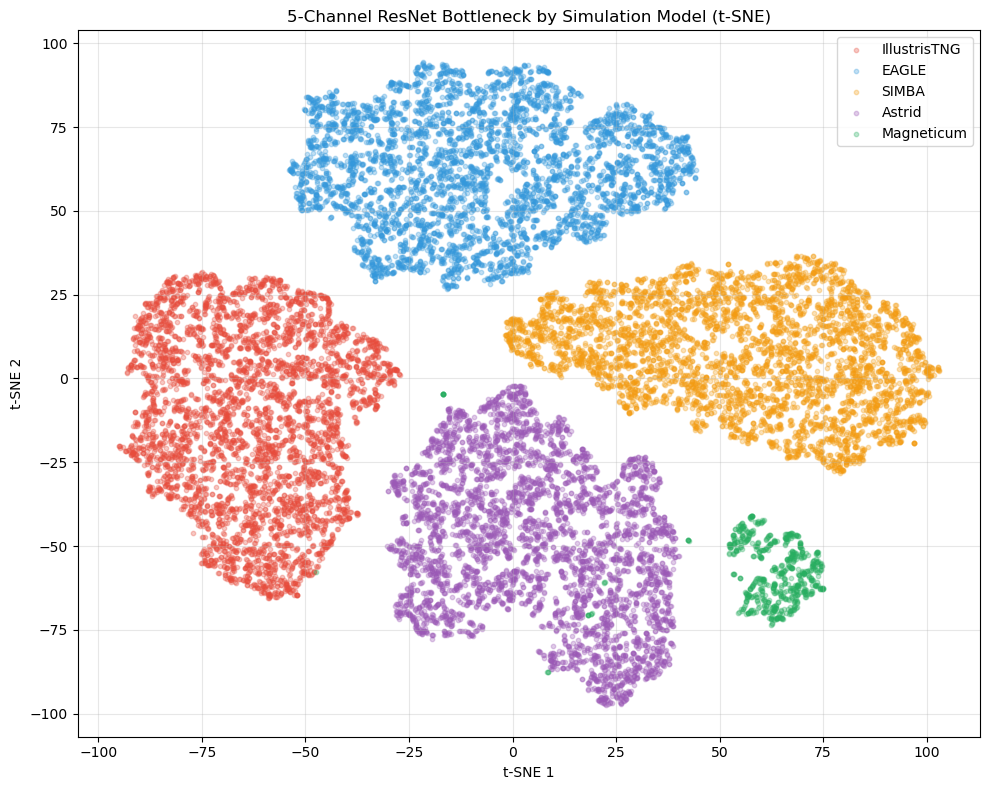

Visualization saved. Total samples: 20720


In [7]:
## Global normlisation

from sklearn.manifold import TSNE

reducer = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=1)
embedding_tsne = reducer.fit_transform(X_resnet)

# Visualize
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6', '#27AE60']
for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels_resnet]
    plt.scatter(embedding_tsne[mask, 0], embedding_tsne[mask, 1], 
               c=colors[i], label='Magneticum (test)' if model_name=='Magneticum' else model_name, alpha=0.3, s=10)
plt.title('5-Channel ResNet Bottleneck by Simulation Model (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_resnet_5chan.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne)}")

In [3]:
def load_model_data(model_name, n_samples=500, data_dir="/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"):
    """Load and normalize data following training pattern exactly"""
    
    # Load full datasets
    # total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mtot_{model_name}_LH_z=0.00.npy')
    total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mcdm_{model_name}_LH_z=0.00.npy')
    star_maps = np.load(f'{data_dir}/{model_name}/Maps_Mstar_{model_name}_LH_z=0.00.npy')
    gas_maps = np.load(f'{data_dir}/{model_name}/Maps_Mgas_{model_name}_LH_z=0.00.npy')
    T_maps = np.load(f'{data_dir}/{model_name}/Maps_T_{model_name}_LH_z=0.00.npy')
    P_maps = np.load(f'{data_dir}/{model_name}/Maps_P_{model_name}_LH_z=0.00.npy')
    params = np.loadtxt(f'{data_dir}/{model_name}/params_LH_{model_name}.txt')
    
    # Apply log1p transformation (training pattern)
    total_mass_log = np.log1p(total_mass)
    star_maps_log = np.log1p(star_maps)
    gas_maps_log = np.log1p(gas_maps)
    T_maps_log = np.log1p(T_maps)
    P_maps_log = np.log1p(P_maps)
    
    # Compute normalization from full dataset
    tot_mean, tot_std = total_mass_log.mean(), total_mass_log.std()
    star_mean, star_std = star_maps_log.mean(), star_maps_log.std()
    gas_mean, gas_std = gas_maps_log.mean(), gas_maps_log.std()
    T_mean, T_std = T_maps_log.mean(), T_maps_log.std()
    P_mean, P_std = P_maps_log.mean(), P_maps_log.std()
    
    # Sample and normalize
    if len(total_mass_log) > n_samples:
        indices = np.random.choice(len(total_mass_log), n_samples, replace=False)
        total_mass = (total_mass_log[indices] - tot_mean) / tot_std
        star_maps = (star_maps_log[indices] - star_mean) / star_std
        gas_maps = (gas_maps_log[indices] - gas_mean) / gas_std
        T_maps = (T_maps_log[indices] - T_mean) / T_std
        P_maps = (P_maps_log[indices] - P_mean) / P_std
        cosmo_params = params[indices//15, :2]  
        astro_params = params[indices//15, 2:]  
    else:
        total_mass = (total_mass_log - tot_mean) / tot_std
        star_maps = (star_maps_log - star_mean) / star_std
        gas_maps = (gas_maps_log - gas_mean) / gas_std
        T_maps = (T_maps_log - T_mean) / T_std
        P_maps = (P_maps_log - P_mean) / P_std
        cosmo_params = np.repeat(params[:,:2],15,axis=0)
        astro_params = np.repeat(params[:,2:],15,axis=0)
    
    return total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params

In [5]:
checkpoint_path = 'lightning_logs/16dim/checkpoints/best-model-epoch=173-val_loss=0.024036.ckpt'
simulation_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid', 'Magneticum']

print("Extracting ResNet features...")
extractor = ResNetBottleneckExtractor(checkpoint_path)

all_features_resnet = []
all_labels_resnet = []

for model_name in simulation_models:
    print(f"Processing {model_name}...")
    total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = load_model_data(model_name, n_samples=5000)
    features = extractor.extract_features(total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params)
    
    if len(features) > 0:
        all_features_resnet.append(features)
        all_labels_resnet.extend([model_name] * len(features))

# UMAP
X_resnet_indv = np.vstack(all_features_resnet)
print(f"Total features: {X_resnet_indv.shape}")

Extracting ResNet features...
Processing IllustrisTNG...
Processing EAGLE...
Processing SIMBA...
Processing Astrid...
Processing Magneticum...
Total features: (20720, 256)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20720 samples in 0.002s...
[t-SNE] Computed neighbors for 20720 samples in 7.161s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20720
[t-SNE] Computed conditional probabilities for sample 2000 / 20720
[t-SNE] Computed conditional probabilities for sample 3000 / 20720
[t-SNE] Computed conditional probabilities for sample 4000 / 20720
[t-SNE] Computed conditional probabilities for sample 5000 / 20720
[t-SNE] Computed conditional probabilities for sample 6000 / 20720
[t-SNE] Computed conditional probabilities for sample 7000 / 20720
[t-SNE] Computed conditional probabilities for sample 8000 / 20720
[t-SNE] Computed conditional probabilities for sample 9000 / 20720
[t-SNE] Computed conditional probabilities for sample 10000 / 20720
[t-SNE] Computed conditional probabilities for sample 11000 / 20720
[t-SNE] Computed conditional probabilities for sample 12000 / 20720
[t-SNE] Computed conditional probabilities for sam

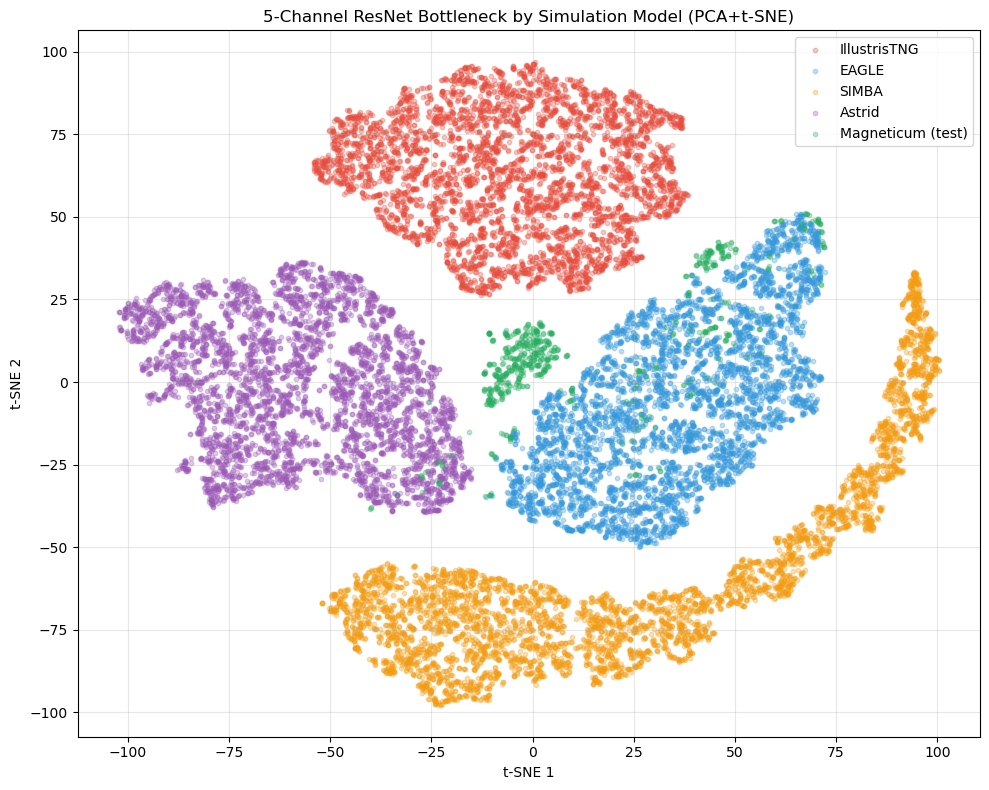

Visualization saved. Total samples: 20720


In [6]:
## Each-simulation normalisation with PCA preprocessing
from sklearn.manifold import TSNE

reducer = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=1)
embedding_tsne_indv = reducer.fit_transform(X_resnet_indv)

# Visualize
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6', '#27AE60']
for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels_resnet]
    plt.scatter(embedding_tsne_indv[mask, 0], embedding_tsne_indv[mask, 1], 
               c=colors[i], label='Magneticum (test)' if model_name=='Magneticum' else model_name, alpha=0.3, s=10)
plt.title('5-Channel ResNet Bottleneck by Simulation Model (PCA+t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_resnet_5chan_indv_pca.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne_indv)}")


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20720 samples in 0.002s...
[t-SNE] Computed neighbors for 20720 samples in 5.411s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20720
[t-SNE] Computed conditional probabilities for sample 2000 / 20720
[t-SNE] Computed conditional probabilities for sample 3000 / 20720
[t-SNE] Computed conditional probabilities for sample 4000 / 20720
[t-SNE] Computed conditional probabilities for sample 5000 / 20720
[t-SNE] Computed conditional probabilities for sample 6000 / 20720
[t-SNE] Computed conditional probabilities for sample 7000 / 20720
[t-SNE] Computed conditional probabilities for sample 8000 / 20720
[t-SNE] Computed conditional probabilities for sample 9000 / 20720
[t-SNE] Computed conditional probabilities for sample 10000 / 20720
[t-SNE] Computed conditional probabilities for sample 11000 / 20720
[t-SNE] Computed conditional probabilities for sample 12000 / 20720
[t-SNE] Computed conditional probabilities for sam

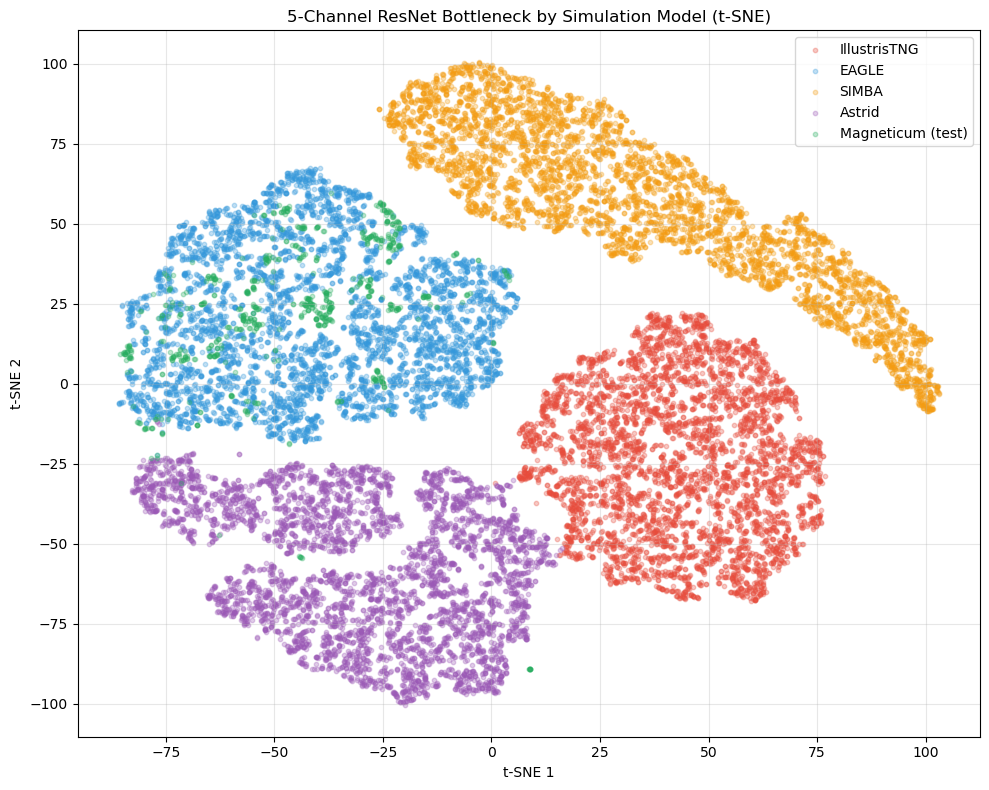

Visualization saved. Total samples: 20720


In [11]:
## Each-simulation normlisation

from sklearn.manifold import TSNE

reducer = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=1)
embedding_tsne_indv = reducer.fit_transform(X_resnet_indv)

# Visualize
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6', '#27AE60']
for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels_resnet]
    plt.scatter(embedding_tsne_indv[mask, 0], embedding_tsne_indv[mask, 1], 
               c=colors[i], label='Magneticum (test)' if model_name=='Magneticum' else model_name, alpha=0.3, s=10)
plt.title('5-Channel ResNet Bottleneck by Simulation Model (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_resnet_5chan_indv.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne_indv)}")

/n/home02/msliu/.conda/envs/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


IndexError: list index out of range

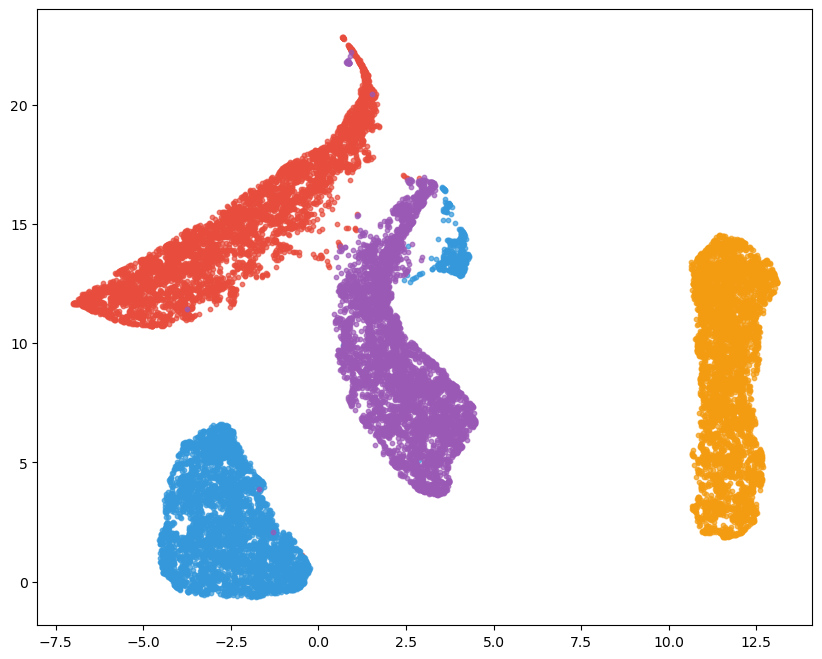

In [15]:
embedding_umap_resnet = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_resnet)
# Plot
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']

for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels_resnet]
    plt.scatter(embedding_umap_resnet[mask, 0], embedding_umap_resnet[mask, 1], 
               c=colors[i], label=model_name, alpha=0.7, s=10)

plt.title('3-Channel ResNet Bottleneck Latent Space by Simulation Model')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("umap_resnet_5chan.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_umap_resnet)}")


Running PCA...
Explained variance ratio: [0.44062153 0.25224882]
Total explained variance: 0.693


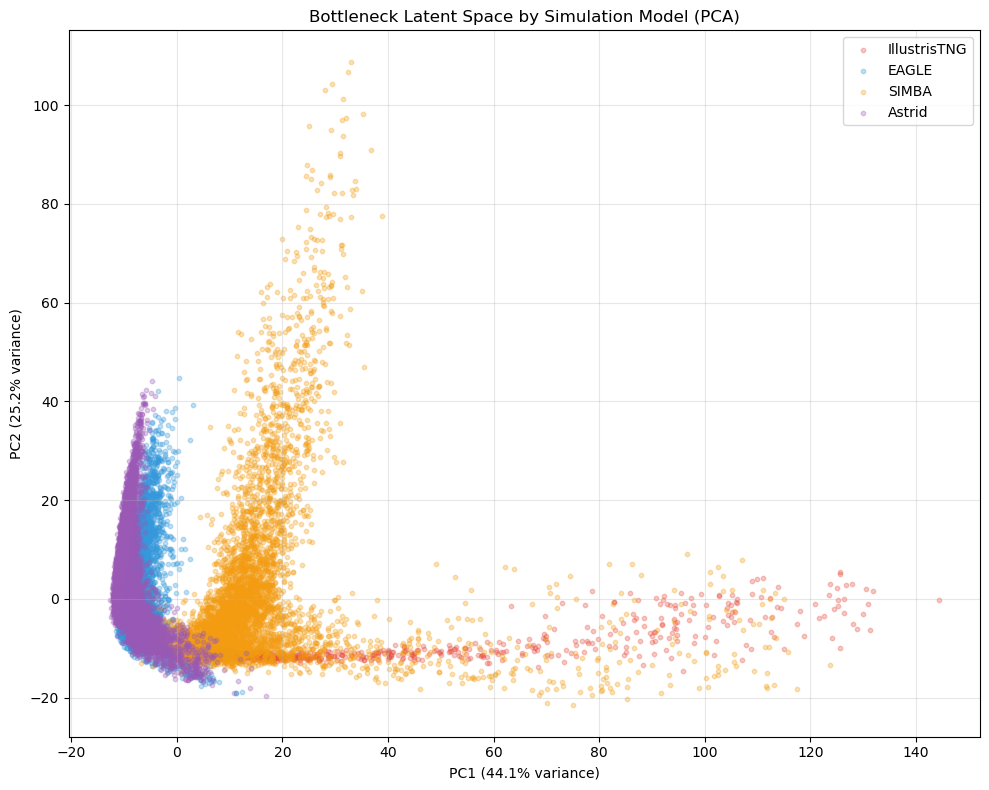

Visualization saved. Total samples: 20000


In [26]:
from sklearn.decomposition import PCA

print("Running PCA...")
stacked_features = np.vstack(all_features[:4])
pca = PCA(n_components=2, random_state=42)
embedding_pca = pca.fit_transform(stacked_features)

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Visualize
plt.figure(figsize=(10, 8))
for i, model_name in enumerate(simulation_models[:4]):
    mask = [label == model_name for label in all_labels[:20000]]
    plt.scatter(embedding_pca[mask, 0], embedding_pca[mask, 1], 
               c=colors[i], label=model_name, alpha=0.3, s=10)

plt.title('Bottleneck Latent Space by Simulation Model (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved. Total samples: {len(embedding_pca)}")

In [4]:
TNG_features, TNG_labels, TNG_astro_params, TNG_cosmo_params = feature_extraction(simulation_models=['IllustrisTNG'],
                                                                                  n_samples_per_model=15000)

Extracting bottleneck features...
Processing IllustrisTNG...
  Extracted 15000 features
  Memory cleared after IllustrisTNG
Total features: (15000, 512)


<>:174: SyntaxWarning: invalid escape sequence '\O'
<>:175: SyntaxWarning: invalid escape sequence '\s'
<>:187: SyntaxWarning: invalid escape sequence '\O'
<>:188: SyntaxWarning: invalid escape sequence '\O'
<>:189: SyntaxWarning: invalid escape sequence '\O'
<>:196: SyntaxWarning: invalid escape sequence '\s'
<>:197: SyntaxWarning: invalid escape sequence '\s'
<>:198: SyntaxWarning: invalid escape sequence '\s'
<>:174: SyntaxWarning: invalid escape sequence '\O'
<>:175: SyntaxWarning: invalid escape sequence '\s'
<>:187: SyntaxWarning: invalid escape sequence '\O'
<>:188: SyntaxWarning: invalid escape sequence '\O'
<>:189: SyntaxWarning: invalid escape sequence '\O'
<>:196: SyntaxWarning: invalid escape sequence '\s'
<>:197: SyntaxWarning: invalid escape sequence '\s'
<>:198: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4183406/3992134669.py:174: SyntaxWarning: invalid escape sequence '\O'
  axes[0, 1].scatter(y_pred[:, 0], residuals_0, alpha=0.5, s=1, label='$\Omega_m$'

Training on device: cuda
Input shape: (15000, 512), Output shape: (15000, 2)
Training on 12000 samples, testing on 3000 samples
------------------------------------------------------------
Epoch   0/100 | Train Loss: 0.122557 | Test Loss: 0.065597
Epoch  10/100 | Train Loss: 0.017441 | Test Loss: 0.011476
Epoch  20/100 | Train Loss: 0.010004 | Test Loss: 0.006768
Epoch  30/100 | Train Loss: 0.006918 | Test Loss: 0.005706
Epoch  40/100 | Train Loss: 0.005929 | Test Loss: 0.005132
Epoch  50/100 | Train Loss: 0.005440 | Test Loss: 0.004799
Epoch  60/100 | Train Loss: 0.005138 | Test Loss: 0.004594
Epoch  70/100 | Train Loss: 0.004997 | Test Loss: 0.004573
Epoch  80/100 | Train Loss: 0.004777 | Test Loss: 0.004411
Epoch  90/100 | Train Loss: 0.004725 | Test Loss: 0.004540
Epoch  99/100 | Train Loss: 0.004551 | Test Loss: 0.004376

FINAL EVALUATION
Parameter 0: MSE = 0.003027 | RMSE = 0.055023 | R² = 0.7705
Parameter 1: MSE = 0.005655 | RMSE = 0.075201 | R² = 0.5830
Overall:     MSE = 0.004

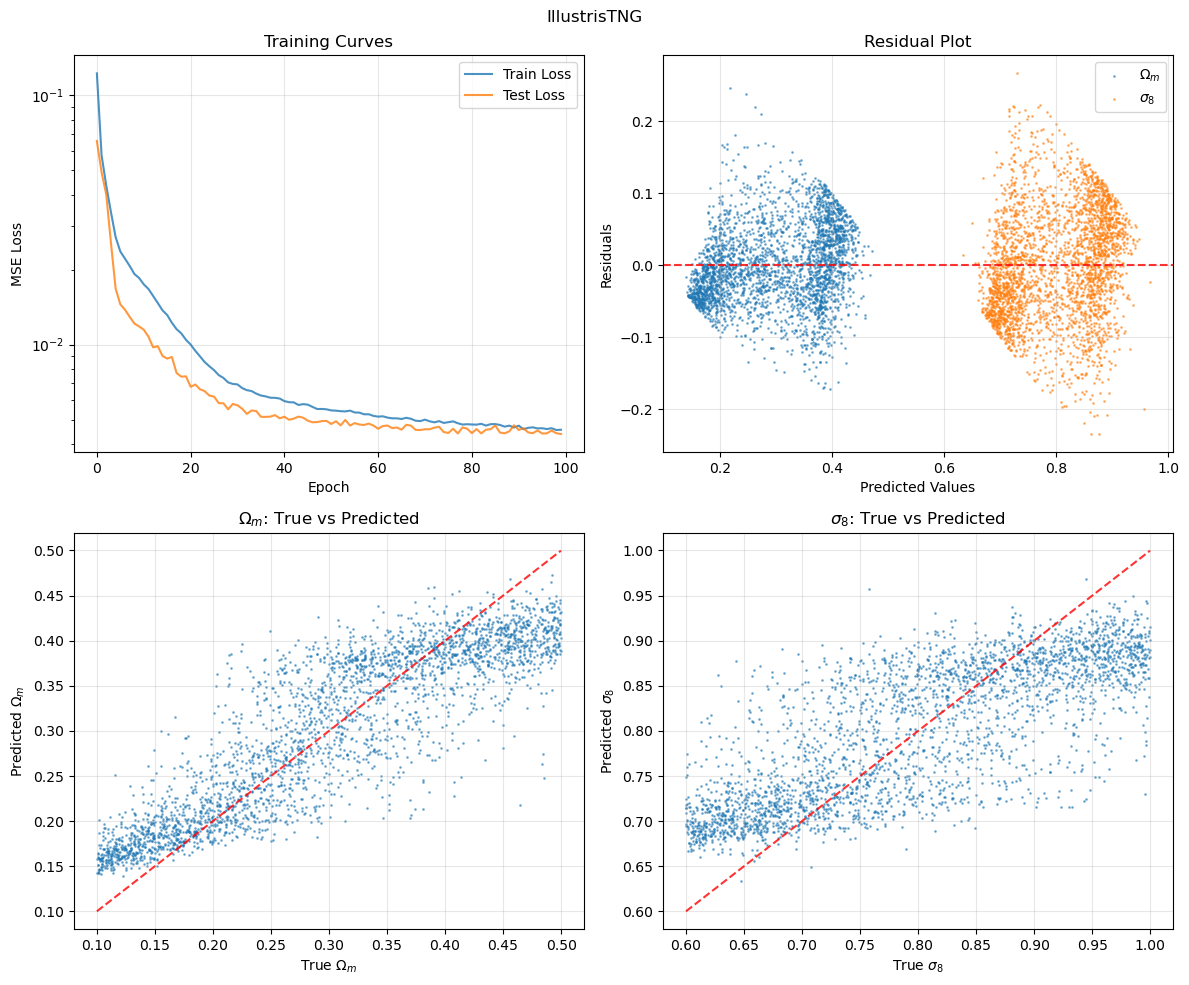

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=512, output_dim=2, hidden_dims=[256, 128, 64]):
        super(SimpleMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Hidden layers
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.6)
            ])
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_mlp(X, y, test_size=0.2, batch_size=128, epochs=100, lr=1e-3, device=None, output_dim=2, model_name='IllustrisTNG'):
    """
    Train MLP on input features and target parameters
    
    Args:
        X: Input features (20000, 512)
        y: Target parameters (20000, 2)
        test_size: Fraction of data for testing
        batch_size: Batch size for training
        epochs: Number of training epochs
        lr: Learning rate
        device: Device to train on
    """
    
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Training on device: {device}")
    print(f"Input shape: {X.shape}, Output shape: {y.shape}")
    
    # Normalize input features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test)
    
    # Create datasets and dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = SimpleMLP(input_dim=512, output_dim=output_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    train_losses = []
    test_losses = []
    
    print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples")
    print("-" * 60)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        test_loss = 0.0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
        
        # Calculate average losses
        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        # Print progress
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
    
    # Final evaluation
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)
    
    model.eval()
    with torch.no_grad():
        X_test_device = X_test_tensor.to(device)
        predictions = model(X_test_device).cpu().numpy()
    
    # Calculate metrics for each parameter
    for i in range(y_test.shape[1]):
        mse = mean_squared_error(y_test[:, i], predictions[:, i])
        r2 = r2_score(y_test[:, i], predictions[:, i])
        rmse = np.sqrt(mse)
        print(f"Parameter {i}: MSE = {mse:.6f} | RMSE = {rmse:.6f} | R² = {r2:.4f}")
    
    # Overall metrics
    overall_mse = mean_squared_error(y_test, predictions)
    overall_r2 = r2_score(y_test, predictions)
    overall_rmse = np.sqrt(overall_mse)
    print(f"Overall:     MSE = {overall_mse:.6f} | RMSE = {overall_rmse:.6f} | R² = {overall_r2:.4f}")
    
    # Plot results
    plot_results(train_losses, test_losses, y_test, predictions, model_name)
    
    return model, scaler, train_losses, test_losses, predictions

def plot_results(train_losses, test_losses, y_true, y_pred, model_name):
    """Plot training curves and prediction results"""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Training curves
    axes[0, 0].plot(train_losses, label='Train Loss', alpha=0.8)
    axes[0, 0].plot(test_losses, label='Test Loss', alpha=0.8)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('MSE Loss')
    axes[0, 0].set_title('Training Curves')
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # Residuals
    residuals_0 = y_true[:, 0] - y_pred[:, 0]
    residuals_1 = y_true[:, 1] - y_pred[:, 1]
    
    axes[0, 1].scatter(y_pred[:, 0], residuals_0, alpha=0.5, s=1, label='$\Omega_m$')
    axes[0, 1].scatter(y_pred[:, 1], residuals_1, alpha=0.5, s=1, label='$\sigma_8$')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
    axes[0, 1].set_xlabel('Predicted Values')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residual Plot')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Parameter 0 predictions
    axes[1, 0].scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 0].min(), y_true[:, 0].max()
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('True $\Omega_m$')
    axes[1, 0].set_ylabel('Predicted $\Omega_m$')
    axes[1, 0].set_title('$\Omega_m$: True vs Predicted')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Parameter 1 predictions
    axes[1, 1].scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 1].min(), y_true[:, 1].max()
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 1].set_xlabel('True $\sigma_8$')
    axes[1, 1].set_ylabel('Predicted $\sigma_8$')
    axes[1, 1].set_title('$\sigma_8$: True vs Predicted')
    axes[1, 1].grid(True, alpha=0.3)
    
    

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig('p(cosmo|zbar).png')
    plt.show()

def predict_parameters(model, scaler, X_new, device=None):
    """Make predictions on new data"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    X_scaled = scaler.transform(X_new)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy()
    
    return predictions

# Train the model
model, scaler, train_losses, test_losses, predictions = train_mlp(np.asarray(TNG_features[0]), 
                                                                  np.asarray(TNG_cosmo_params[0]),
                                                                  model_name='IllustrisTNG')

# Make predictions on new data
# new_predictions = predict_parameters(model, scaler, np.asarray(all_features[0]))


Training on device: cuda
Input shape: (15000, 512), Output shape: (15000, 4)
Training on 12000 samples, testing on 3000 samples
------------------------------------------------------------
Epoch   0/100 | Train Loss: 0.265257 | Test Loss: 0.151207
Epoch  10/100 | Train Loss: 0.091926 | Test Loss: 0.082103
Epoch  20/100 | Train Loss: 0.080251 | Test Loss: 0.076164
Epoch  30/100 | Train Loss: 0.074133 | Test Loss: 0.072980
Epoch  40/100 | Train Loss: 0.072413 | Test Loss: 0.071593
Epoch  50/100 | Train Loss: 0.071537 | Test Loss: 0.070184
Epoch  60/100 | Train Loss: 0.070121 | Test Loss: 0.070674
Epoch  70/100 | Train Loss: 0.069396 | Test Loss: 0.070349
Epoch  80/100 | Train Loss: 0.068361 | Test Loss: 0.070519
Epoch  90/100 | Train Loss: 0.066803 | Test Loss: 0.070595
Epoch  99/100 | Train Loss: 0.065650 | Test Loss: 0.070396

FINAL EVALUATION
Parameter 0: MSE = 0.057891 | RMSE = 0.240604 | R² = 0.6466
Parameter 1: MSE = 0.161867 | RMSE = 0.402327 | R² = 0.0031
Parameter 2: MSE = 0.025

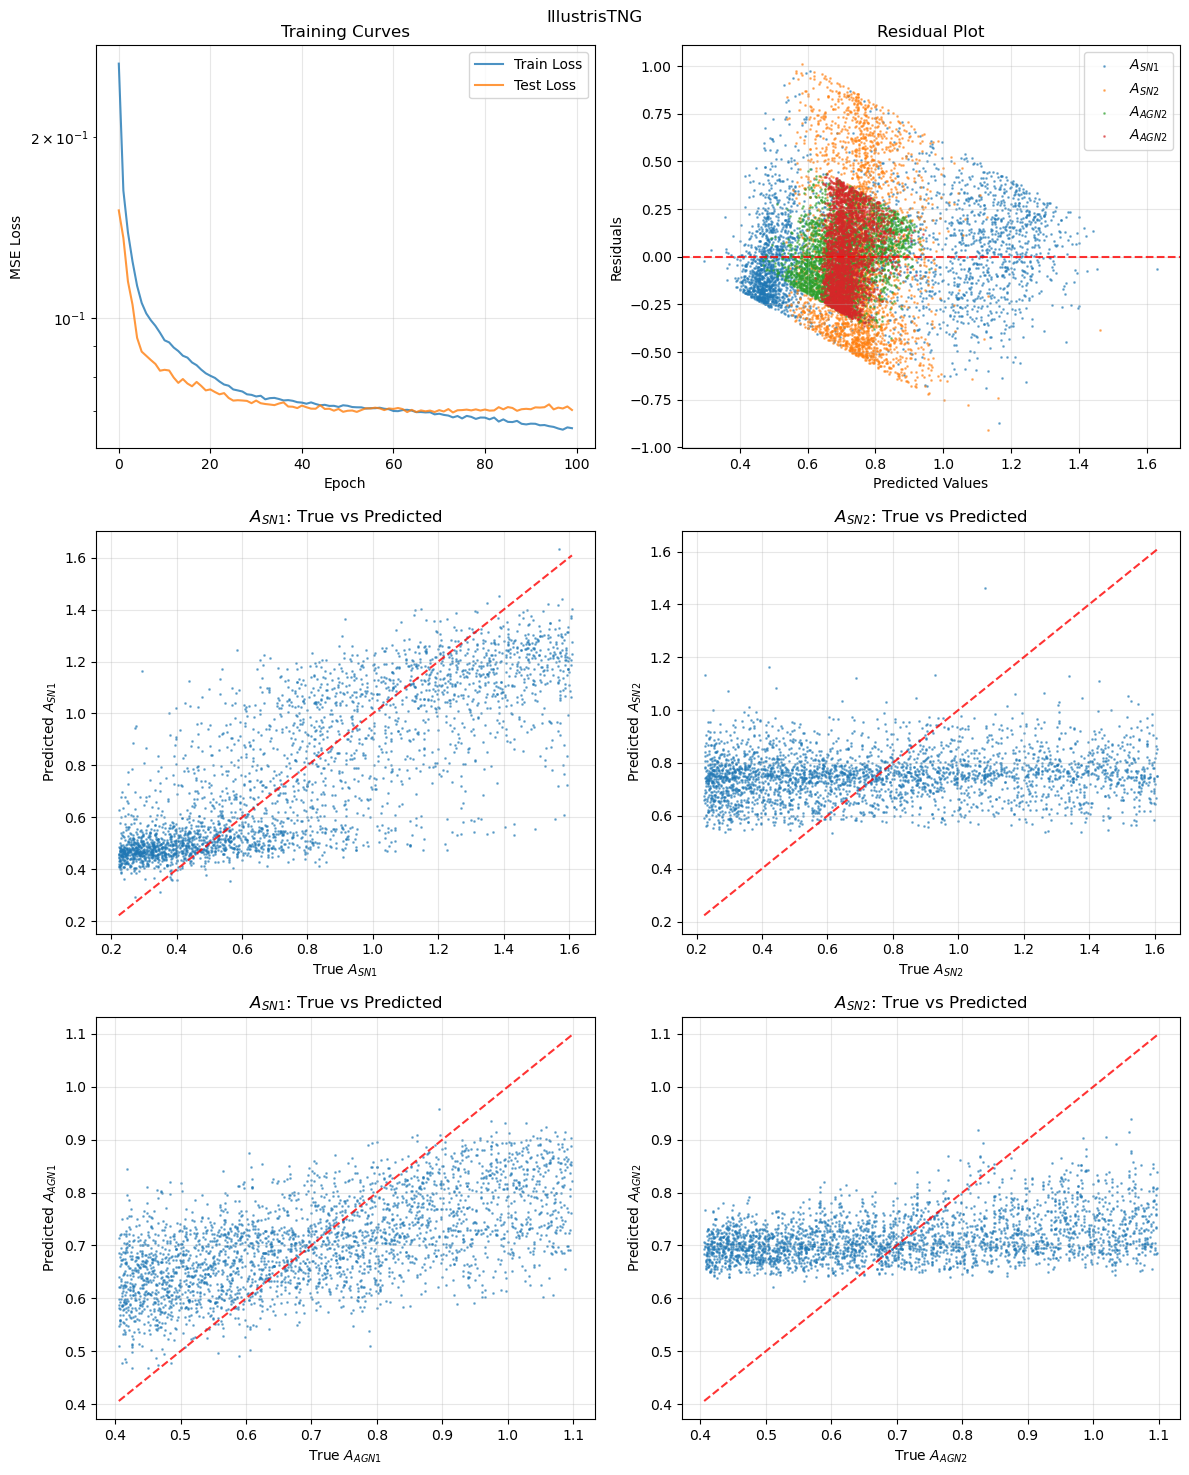

In [29]:
def plot_results(train_losses, test_losses, y_true, y_pred, model_name):
    """Plot training curves and prediction results"""
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    
    # Training curves
    axes[0, 0].plot(train_losses, label='Train Loss', alpha=0.8)
    axes[0, 0].plot(test_losses, label='Test Loss', alpha=0.8)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('MSE Loss')
    axes[0, 0].set_title('Training Curves')
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # Residuals
    residuals_0 = y_true[:, 0] - y_pred[:, 0]
    residuals_1 = y_true[:, 1] - y_pred[:, 1]
    residuals_2 = y_true[:, 2] - y_pred[:, 2]
    residuals_3 = y_true[:, 3] - y_pred[:, 3]
    
    axes[0, 1].scatter(y_pred[:, 0], residuals_0, alpha=0.5, s=1, label='$A_{SN1}$')
    axes[0, 1].scatter(y_pred[:, 1], residuals_1, alpha=0.5, s=1, label='$A_{SN2}$')
    axes[0, 1].scatter(y_pred[:, 2], residuals_2, alpha=0.5, s=1, label='$A_{AGN2}$')
    axes[0, 1].scatter(y_pred[:, 3], residuals_3, alpha=0.5, s=1, label='$A_{AGN2}$')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
    axes[0, 1].set_xlabel('Predicted Values')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residual Plot')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Parameter 0 predictions
    axes[1, 0].scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 0].min(), y_true[:, 0].max()
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('True $A_{SN1}$')
    axes[1, 0].set_ylabel('Predicted $A_{SN1}$')
    axes[1, 0].set_title('$A_{SN1}$: True vs Predicted')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Parameter 1 predictions
    axes[1, 1].scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 1].min(), y_true[:, 1].max()
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 1].set_xlabel('True $A_{SN2}$')
    axes[1, 1].set_ylabel('Predicted $A_{SN2}$')
    axes[1, 1].set_title('$A_{SN2}$: True vs Predicted')
    axes[1, 1].grid(True, alpha=0.3)

    # Parameter 3 predictions
    axes[2, 0].scatter(y_true[:, 2], y_pred[:, 2], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 2].min(), y_true[:, 2].max()
    axes[2, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[2, 0].set_xlabel('True $A_{AGN1}$')
    axes[2, 0].set_ylabel('Predicted $A_{AGN1}$')
    axes[2, 0].set_title('$A_{SN1}$: True vs Predicted')
    axes[2, 0].grid(True, alpha=0.3)
    
    # Parameter 4 predictions
    axes[2, 1].scatter(y_true[:, 3], y_pred[:, 3], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 3].min(), y_true[:, 3].max()
    axes[2, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[2, 1].set_xlabel('True $A_{AGN2}$')
    axes[2, 1].set_ylabel('Predicted $A_{AGN2}$')
    axes[2, 1].set_title('$A_{SN2}$: True vs Predicted')
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig('p(astro|zbar).png')
    plt.show()

def predict_parameters(model, scaler, X_new, device=None):
    """Make predictions on new data"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    X_scaled = scaler.transform(X_new)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy()
    
    return predictions

# Train the model
model, scaler, train_losses, test_losses, predictions = train_mlp(TNG_features[0], np.log1p(TNG_astro_params[0]), epochs=100, output_dim=4)

# Make predictions on new data
# new_predictions = predict_parameters(model, scaler, X)


Training on device: cuda
Input shape: (15000, 512), Output shape: (15000, 2)
Training on 12000 samples, testing on 3000 samples
------------------------------------------------------------
Epoch   0/200 | Train Loss: 0.334461 | Test Loss: 0.250790
Epoch  10/200 | Train Loss: 0.199653 | Test Loss: 0.189594
Epoch  20/200 | Train Loss: 0.176388 | Test Loss: 0.166888
Epoch  30/200 | Train Loss: 0.159531 | Test Loss: 0.160666
Epoch  40/200 | Train Loss: 0.151523 | Test Loss: 0.156378
Epoch  50/200 | Train Loss: 0.145273 | Test Loss: 0.153133
Epoch  60/200 | Train Loss: 0.138169 | Test Loss: 0.151653
Epoch  70/200 | Train Loss: 0.135064 | Test Loss: 0.155336
Epoch  80/200 | Train Loss: 0.129691 | Test Loss: 0.151053
Epoch  90/200 | Train Loss: 0.126627 | Test Loss: 0.151190
Epoch 100/200 | Train Loss: 0.125687 | Test Loss: 0.152863
Epoch 110/200 | Train Loss: 0.121746 | Test Loss: 0.153995
Epoch 120/200 | Train Loss: 0.121629 | Test Loss: 0.149548
Epoch 130/200 | Train Loss: 0.117873 | Test 

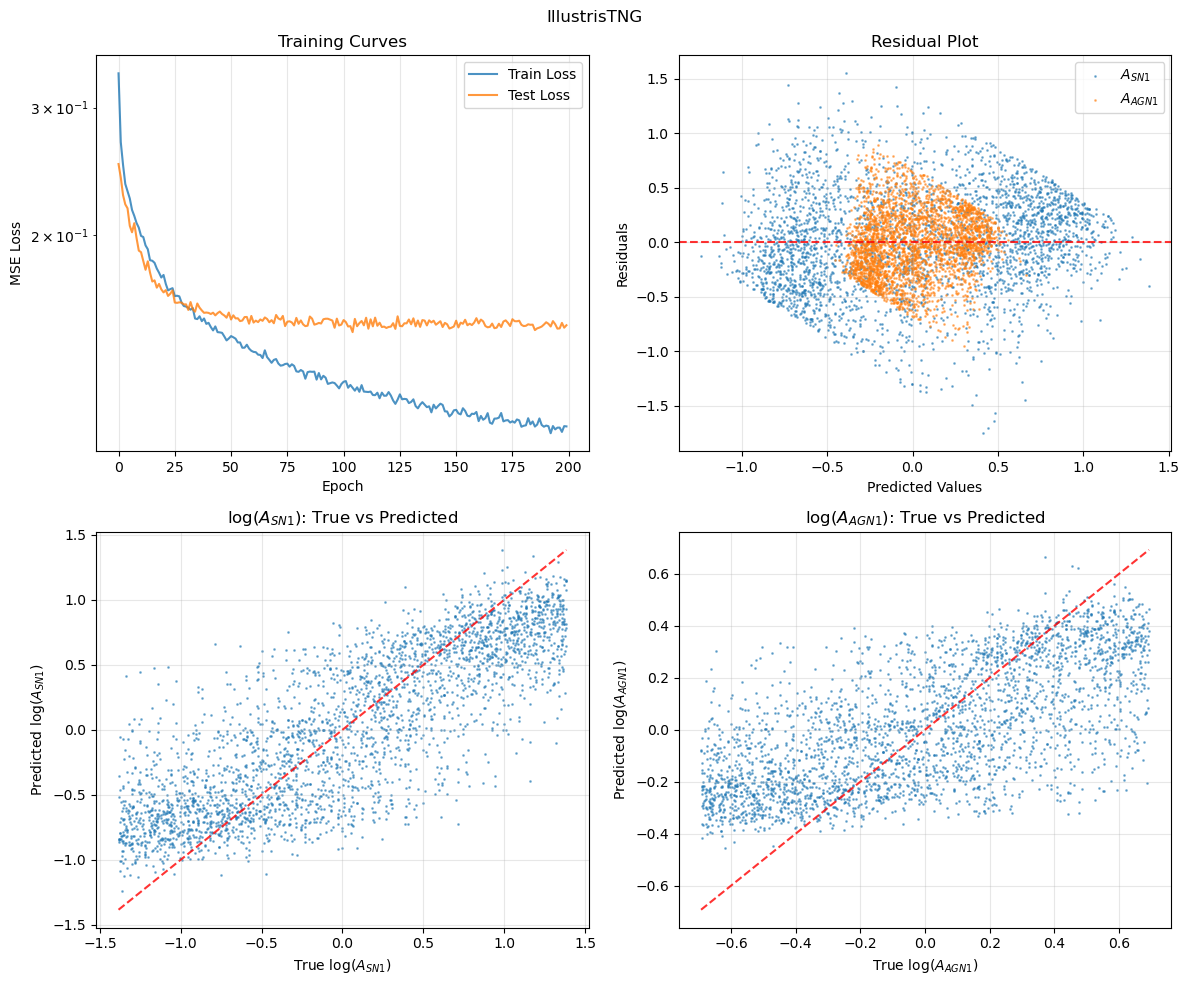

In [30]:
def plot_results(train_losses, test_losses, y_true, y_pred, model_name):
    """Plot training curves and prediction results"""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Training curves
    axes[0, 0].plot(train_losses, label='Train Loss', alpha=0.8)
    axes[0, 0].plot(test_losses, label='Test Loss', alpha=0.8)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('MSE Loss')
    axes[0, 0].set_title('Training Curves')
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # Residuals
    residuals_0 = y_true[:, 0] - y_pred[:, 0]
    residuals_1 = y_true[:, 1] - y_pred[:, 1]
    
    axes[0, 1].scatter(y_pred[:, 0], residuals_0, alpha=0.5, s=1, label='$A_{SN1}$')
    axes[0, 1].scatter(y_pred[:, 1], residuals_1, alpha=0.5, s=1, label='$A_{AGN1}$')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
    axes[0, 1].set_xlabel('Predicted Values')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residual Plot')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Parameter 0 predictions
    axes[1, 0].scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 0].min(), y_true[:, 0].max()
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('True log($A_{SN1}$)')
    axes[1, 0].set_ylabel('Predicted log($A_{SN1}$)')
    axes[1, 0].set_title('log($A_{SN1}$): True vs Predicted')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Parameter 1 predictions
    axes[1, 1].scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 1].min(), y_true[:, 1].max()
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 1].set_xlabel('True log($A_{AGN1}$)')
    axes[1, 1].set_ylabel('Predicted log($A_{AGN1}$)')
    axes[1, 1].set_title('log($A_{AGN1}$): True vs Predicted')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig('p(astro|zbar).png')
    plt.show()

def predict_parameters(model, scaler, X_new, device=None):
    """Make predictions on new data"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    X_scaled = scaler.transform(X_new)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy()
    
    return predictions

# Train the model
model, scaler, train_losses, test_losses, predictions = train_mlp(np.asarray(TNG_features[0]), np.log(np.asarray(TNG_astro_params[0])[:,[0,2]]), 
                                                                  model_name = 'IllustrisTNG', epochs=200, output_dim=2)



In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse

In [57]:
class MixtureDensityNetwork(nn.Module):
    def __init__(self, input_dim=512, output_dim=2, hidden_dims=[128, 64], n_components=3):
        super(MixtureDensityNetwork, self).__init__()
        
        self.output_dim = output_dim
        self.n_components = n_components
        
        # Shared hidden layers
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.5)  # Reduced dropout for MDN
            ])
            prev_dim = hidden_dim
        
        self.shared_layers = nn.Sequential(*layers)
        
        # Output heads
        # Mixture weights (pi)
        self.pi_head = nn.Linear(prev_dim, n_components)
        
        # Means (mu) for each component
        self.mu_head = nn.Linear(prev_dim, n_components * output_dim)
        
        # Log variances (sigma) for each component (diagonal covariance)
        self.sigma_head = nn.Linear(prev_dim, n_components * output_dim)
        
    def forward(self, x):
        # Shared representation
        h = self.shared_layers(x)
        
        # Mixture weights (softmax to ensure they sum to 1)
        pi = F.softmax(self.pi_head(h), dim=1)
        
        # Means (reshape to [batch_size, n_components, output_dim])
        mu = self.mu_head(h).view(-1, self.n_components, self.output_dim)
        
        # Variances (exp to ensure positive, reshape)
        sigma_raw = self.sigma_head(h)
        sigma = torch.exp(torch.clamp(sigma_raw, min=-10, max=10)).view(-1, self.n_components, self.output_dim)
        sigma = torch.clamp(sigma, min=1e-6, max=100)
        
        return pi, mu, sigma

def mdn_loss(pi, mu, sigma, target):
    """
    Compute the negative log-likelihood loss for MDN
    """
    batch_size, n_components, output_dim = mu.shape
    
    # Expand target to match component dimensions
    target_expanded = target.unsqueeze(1).expand(-1, n_components, -1)
    
    # Compute log probabilities for each component (assuming diagonal covariance)
    log_prob_components = torch.zeros(batch_size, n_components, device=mu.device)
    
    for i in range(n_components):
        # Compute log probability for each component (multivariate normal with diagonal covariance)
        diff = target_expanded[:, i, :] - mu[:, i, :]
        log_prob = -0.5 * torch.sum((diff / sigma[:, i, :]) ** 2, dim=1)
        log_prob -= torch.sum(torch.log(sigma[:, i, :]), dim=1)
        log_prob -= 0.5 * output_dim * torch.log(2 * torch.tensor(np.pi))
        log_prob_components[:, i] = log_prob
    
    # Compute mixture probability
    log_pi = torch.log(torch.clamp(pi, min=1e-8, max=1.0))  # Prevent log(0)
    log_prob_mixture = torch.logsumexp(log_pi + log_prob_components, dim=1)
    
    # Return negative log-likelihood
    return -torch.mean(log_prob_mixture)

def sample_from_mdn(pi, mu, sigma, n_samples=1000):
    """
    Sample from the mixture density network
    """
    batch_size, n_components, output_dim = mu.shape
    
    # For simplicity, assume single input (batch_size=1)
    if batch_size > 1:
        # Take first sample in batch
        pi = pi[0:1]
        mu = mu[0:1]
        sigma = sigma[0:1]
    
    pi = pi.squeeze(0).cpu().numpy()
    mu = mu.squeeze(0).cpu().numpy()
    sigma = sigma.squeeze(0).cpu().numpy()
    
    samples = []
    
    for _ in range(n_samples):
        # Sample component
        component = np.random.choice(n_components, p=pi)
        
        # Sample from chosen component (diagonal covariance)
        sample = np.random.normal(mu[component], sigma[component])
        samples.append(sample)
    
    return np.array(samples)

In [95]:
def train_mdn(X, y, test_size=0.2, batch_size=128, epochs=200, lr=1e-3, device=None, n_components=3):
    """
    Train Mixture Density Network
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Training MDN on device: {device}")
    print(f"Input shape: {X.shape}, Output shape: {y.shape}")
    
    # Normalize input features
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()

    X_scaled = input_scaler.fit_transform(X)
    y_scaled = output_scaler.fit_transform(y)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_scaled, test_size=test_size, random_state=42
    )
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).to(device)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.FloatTensor(y_test).to(device)
    
    # Create datasets and dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = MixtureDensityNetwork(
        input_dim=X.shape[1], 
        output_dim=y.shape[1], 
        n_components=n_components
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # Training loop
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pi, mu, sigma = model(batch_X)
            loss = mdn_loss(pi, mu, sigma, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                pi, mu, sigma = model(batch_X)
                loss = mdn_loss(pi, mu, sigma, batch_y)
                test_loss += loss.item()
        
        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        if epoch % 20 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
    
    return model, input_scaler, output_scaler, train_losses, test_losses, X_test, y_test

In [92]:
def sample_posterior_mdn(model, X_input, input_scaler, output_scaler, device, n_samples=5000):
    """
    Sample from the posterior distribution for given inputs using MDN
    """
    model.eval()
    X_scaled = input_scaler.transform(X_input)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    all_samples = []
    
    with torch.no_grad():
        pi, mu, sigma = model(X_tensor)
        
        # Convert to numpy for sampling
        pi_np = pi.cpu().numpy()
        mu_np = mu.cpu().numpy() 
        sigma_np = sigma.cpu().numpy()
        
        for i in range(X_input.shape[0]):
            # Sample from mixture for this input
            samples = sample_from_mdn(
                torch.tensor(pi_np[i:i+1]), 
                torch.tensor(mu_np[i:i+1]), 
                torch.tensor(sigma_np[i:i+1]), 
                n_samples
            )
            samples_rescaled = output_scaler.inverse_transform(samples)
            all_samples.append(samples_rescaled)
    
    return np.array(all_samples)

def create_corner_plot(samples, true_values=None, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'], 
                      title="Posterior Distribution", figsize=(15, 15), 
                      n_contour_levels=3, alpha=0.6):
    """
    Create a corner plot showing joint and marginal posterior distributions
    """
    
    # Handle different input shapes
    if len(samples.shape) == 3:
        # Multiple datapoints: flatten samples from all datapoints
        n_datapoints, n_samples_per_point, n_params = samples.shape
        samples_flat = samples.reshape(-1, n_params)
        print(f"Plotting posterior from {n_datapoints} datapoints with {n_samples_per_point} samples each")
    else:
        # Single set of samples
        samples_flat = samples
        n_params = samples.shape[1]
        print(f"Plotting posterior from {samples.shape[0]} samples")
    
    fig, axes = plt.subplots(n_params, n_params, figsize=figsize)
    
    if n_params == 1:
        axes = np.array([[axes]])
    elif n_params == 2:
        pass  # axes is already correct shape
    
    # Color scheme
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            
            if i < j:
                # Upper triangle: hide
                ax.set_visible(False)
                continue
            elif i == j:
                # Diagonal: marginal distributions
                data = samples_flat[:, i]
                
                # Add KDE smooth curve
                try:
                    kde = gaussian_kde(data)
                    x_kde = np.linspace(data.min(), data.max(), 200)
                    ax.plot(x_kde, kde(x_kde), color='darkred', linewidth=2, alpha=0.8)
                    ax.fill_between(x_kde, kde(x_kde), alpha=0.3, color='darkred')
                except:
                    pass  # Skip KDE if it fails
                
                ax.set_ylabel('Density')
                if i == n_params - 1:
                    ax.set_xlabel(param_names[i])
                
            else:
                # Lower triangle: joint distributions
                x_data = samples_flat[:, j]
                y_data = samples_flat[:, i]
                
                # Create 2D histogram for contours (sunny egg style)
                try:
                    # Estimate 2D density using histogram + smoothing
                    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=30, density=True)
                    from scipy.ndimage import gaussian_filter
                    H = gaussian_filter(H, sigma=1.0)
                    X_grid, Y_grid = np.meshgrid(xedges[:-1], yedges[:-1])
                    density = H.T
                    
                    # Sunny egg color scheme
                    from matplotlib.colors import to_rgba
                    base_color = colors[0]  # Use first color as base
                    base_rgba = to_rgba(base_color)
                    
                    # Outer: lighter (mix with white)
                    mix_factor = 0.7
                    outer_color = tuple(base_rgba[k] * (1-mix_factor) + mix_factor for k in range(3)) + (1.0,)
                    
                    # Inner: darker (multiply RGB values)
                    darken_factor = 0.8
                    inner_color = tuple(base_rgba[k] * darken_factor for k in range(3)) + (1.0,)
                    
                    # Create two levels for sunny egg effect based on density percentiles
                    max_density = density.max()
                    min_density = density.min()
                    
                    # Use percentiles of the actual density values
                    low_level = np.percentile(density, 85)   # 85th percentile
                    high_level = np.percentile(density, 95)  # 95th percentile
                    
                    # Ensure we have meaningful levels
                    if low_level >= high_level:
                        low_level = min_density + (max_density - min_density) * 0.5
                        high_level = min_density + (max_density - min_density) * 0.9
                    
                    levels_to_use = [low_level, high_level]
                    
                    # Fill outer ring (lighter)
                    ax.contourf(X_grid, Y_grid, density, 
                               levels=[levels_to_use[0], levels_to_use[1]], 
                               colors=[outer_color], alpha=0.8)
                    
                    # Fill inner core (darker)
                    ax.contourf(X_grid, Y_grid, density, 
                               levels=[levels_to_use[1], max_density], 
                               colors=[inner_color], alpha=0.8)
                    
                except:
                    # Fallback to scatter plot if KDE fails
                    n_plot = min(2000, len(x_data))  # Limit points for performance
                    indices = np.random.choice(len(x_data), n_plot, replace=False)
                    ax.scatter(x_data[indices], y_data[indices], alpha=alpha, s=1, 
                             color=colors[0], rasterized=True)
                if i == n_params - 1:
                    ax.set_xlabel(param_names[j])
                if j == 0:
                    ax.set_ylabel(param_names[i])
            
            # Styling
            ax.grid(True, alpha=0.3)
            if i == 0 and j == 0 and true_values is not None:
                ax.legend(fontsize=8)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig('posterior.png')
    return fig, axes

def demo_corner_plot(model, input_scaler, output_scaler, X_test, y_test, device, n_points=5):
    """
    Create corner plots for a few example test points
    """
    # Select a few interesting test points
    indices = np.random.choice(len(X_test), n_points, replace=False)
    X_demo = X_test[indices]
    y_demo = y_test[indices]
    
    # Sample posteriors
    posterior_samples = sample_posterior_mdn(model, X_demo, input_scaler, output_scaler, device, n_samples=3000)
    
    # Create corner plot
    fig, axes = create_corner_plot(
        posterior_samples, 
        true_values=y_demo,
        title=f"Posterior Distributions"
    )
    
    return fig, posterior_samples

def analyze_posterior_quality(model, scaler, X_test, y_test, device, n_samples=1000):
    """
    Analyze the quality of posterior estimates
    """
    # Sample a subset for analysis
    n_analyze = min(100, len(X_test))
    indices = np.random.choice(len(X_test), n_analyze, replace=False)
    X_subset = X_test[indices]
    y_subset = y_test[indices]
    
    # Get posterior samples
    posterior_samples = sample_posterior_mdn(model, X_subset, scaler, device, n_samples)
    
    # Calculate statistics
    posterior_means = np.mean(posterior_samples, axis=1)
    posterior_stds = np.std(posterior_samples, axis=1)
    
    # Check if true values fall within confidence intervals
    z_scores = np.abs(y_subset - posterior_means) / posterior_stds
    within_1sigma = np.mean(z_scores < 1, axis=0)
    within_2sigma = np.mean(z_scores < 2, axis=0)
    
    print("Posterior Quality Analysis:")
    print(f"Fraction of true values within 1σ: Ωₘ={within_1sigma[0]:.3f}, σ₈={within_1sigma[1]:.3f}")
    print(f"Fraction of true values within 2σ: Ωₘ={within_2sigma[0]:.3f}, σ₈={within_2sigma[1]:.3f}")
    print(f"Expected within 1σ: 0.683, within 2σ: 0.955")
    
    return posterior_samples, posterior_means, posterior_stds

<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_338873/744083885.py:32: SyntaxWarning: invalid escape sequence '\O'
  def create_corner_plot(samples, true_values=None, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'],
/tmp/ipykernel_338873/744083885.py:32: SyntaxWarning: invalid escape sequence '\s'
  def create_corner_plot(samples, true_values=None, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'],


In [93]:
def run_complete_example(features, cosmo_params, astro_params):
    """
    Complete example - replace with your actual data
    """
    # Example with synthetic data - replace with your actual data
    print("Creating synthetic data for demonstration...")
    
    extracted_features = np.asarray(features).squeeze()
    parameters = np.concatenate((cosmo_params,np.asarray(astro_params)[:,:,[0,2]]),axis=2).squeeze()

    print(f"Combined params range: [{parameters.min():.3f}, {parameters.max():.3f}]")
    print(f"Combined params shape: {parameters.shape}")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Train MDN
    print("\nTraining MDN...")
    model, input_scaler, output_scaler, train_losses, test_losses, X_test, y_test = train_mdn(
        extracted_features, parameters, n_components=2, epochs=100 
    )
    
    # Create corner plot
    print("\nCreating corner plot...")
    fig, posterior_samples = demo_corner_plot(model, input_scaler, output_scaler, X_test, y_test, device, n_points=5)
    plt.show()
    
    # Analyze posterior quality
    print("\nAnalyzing posterior quality...")
    samples, means, stds = analyze_posterior_quality(model, scaler, X_test, y_test, device)
    
    return model, scaler, X_test, y_test

In [ ]:
model, scaler, X_test, y_test = run_complete_example(TNG_features, TNG_cosmo_params, TNG_astro_params)

Creating synthetic data for demonstration...
Combined params range: [0.100, 3.994]
Combined params shape: (15000, 4)
Using device: cuda

Training MDN...
Training MDN on device: cuda
Input shape: (15000, 512), Output shape: (15000, 4)
Epoch   0/100 | Train Loss: 5.491477 | Test Loss: 5.084237
Epoch  20/100 | Train Loss: 3.724830 | Test Loss: 3.457135
Epoch  40/100 | Train Loss: 3.477302 | Test Loss: 3.352745
Epoch  60/100 | Train Loss: 3.343639 | Test Loss: 3.271054


In [71]:
TNG_features, TNG_labels, TNG_astro_params, TNG_cosmo_params = feature_extraction(simulation_models=['IllustrisTNG'],
                                                                                  n_samples_per_model=15000)
EAGLE_features, EAGLE_labels, EAGLE_astro_params, EAGLE_cosmo_params = feature_extraction(simulation_models=['EAGLE'],
                                                                                  n_samples_per_model=15000)
Astrid_features, Astrid_labels, Astrid_astro_params, Astrid_cosmo_params = feature_extraction(simulation_models=['Astrid'],
                                                                                  n_samples_per_model=15000)
SIMBA_features, SIMBA_labels, SIMBA_astro_params, SIMBA_cosmo_params = feature_extraction(simulation_models=['SIMBA'],
                                                                                  n_samples_per_model=15000)

Extracting bottleneck features...
Processing IllustrisTNG...
  Extracted 15000 features
  Memory cleared after IllustrisTNG
Total features: (15000, 512)
Extracting bottleneck features...
Processing EAGLE...
  Extracted 15000 features
  Memory cleared after EAGLE
Total features: (15000, 512)
Extracting bottleneck features...
Processing Astrid...
  Extracted 15000 features
  Memory cleared after Astrid
Total features: (15000, 512)
Extracting bottleneck features...
Processing SIMBA...
  Extracted 15000 features
  Memory cleared after SIMBA
Total features: (15000, 512)


In [72]:
def create_multi_simulation_corner_plot(models_data, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'], 
                                       figsize=(15, 15), n_samples_per_model=3000, n_points_per_model=10):
    """
    Create a combined corner plot from multiple simulation models
    
    Args:
        models_data: List of dictionaries, each containing:
            {
                'model': trained MDN model,
                'scaler': fitted scaler,
                'X_test': test features,
                'y_test': test parameters,
                'device': torch device,
                'name': simulation name (e.g., 'IllustrisTNG', 'EAGLE', etc.),
                'color': color for this simulation
            }
        param_names: List of parameter names for axis labels
        figsize: Figure size
        n_samples_per_model: Number of posterior samples per model
        n_points_per_model: Number of test points to use per model
    
    Returns:
        fig, axes: matplotlib figure and axes
        all_samples: Dictionary of posterior samples by simulation
    """
    
    print(f"Creating combined corner plot for {len(models_data)} simulation models...")
    
    # Colors for different simulations (fallback if not provided)
    default_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
    
    # Sample posteriors from each model
    all_samples = {}
    
    for i, model_data in enumerate(models_data):
        model = model_data['model']
        scaler = model_data['scaler'] 
        X_test = model_data['X_test']
        y_test = model_data['y_test']
        device = model_data['device']
        sim_name = model_data.get('name', f'Simulation_{i+1}')
        
        print(f"Sampling from {sim_name}...")
        
        # Select random test points for this model
        n_available = len(X_test)
        n_to_use = min(n_points_per_model, n_available)
        indices = np.random.choice(n_available, n_to_use, replace=False)
        X_demo = X_test[indices]
        
        # Sample posteriors
        posterior_samples = sample_posterior_mdn(model, X_demo, scaler, device, n_samples=n_samples_per_model)
        
        # Flatten samples from all test points for this simulation
        samples_flat = posterior_samples.reshape(-1, posterior_samples.shape[-1])
        
        all_samples[sim_name] = {
            'samples': samples_flat,
            'color': model_data.get('color', default_colors[i % len(default_colors)]),
            'n_points': n_to_use,
            'n_samples': len(samples_flat)
        }
    
    # Create corner plot
    n_params = len(param_names)
    fig, axes = plt.subplots(n_params, n_params, figsize=figsize)
    
    if n_params == 1:
        axes = np.array([[axes]])
    
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            
            if i < j:
                # Upper triangle: hide
                ax.set_visible(False)
                continue
            elif i == j:
                # Diagonal: marginal distributions for each simulation
                for sim_name, sim_data in all_samples.items():
                    samples = sim_data['samples']
                    color = sim_data['color']
                    data = samples[:, i]
                    
                    if len(data) > 10:  # Only plot if we have enough data
                        try:
                            kde = gaussian_kde(data)
                            x_range = np.linspace(data.min(), data.max(), 200)
                            density = kde(x_range)
                            ax.plot(x_range, density, color=color, linewidth=2, 
                                   alpha=0.8, label=sim_name)
                            ax.fill_between(x_range, density, alpha=0.3, color=color)
                        except:
                            # Fallback to histogram
                            ax.hist(data, bins=30, density=True, alpha=0.5, 
                                   color=color, label=sim_name, histtype='step', linewidth=2)
                
                ax.set_ylabel('Density', fontsize=12)
                if i == n_params - 1:
                    ax.set_xlabel(param_names[i], fontsize=12)
                
                # Add legend to first diagonal plot
                if i == 0:
                    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
                
            else:
                # Lower triangle: joint distributions with sunny egg style
                for sim_name, sim_data in all_samples.items():
                    samples = sim_data['samples']
                    color = sim_data['color']
                    x_data = samples[:, j]  # x-axis dimension
                    y_data = samples[:, i]  # y-axis dimension
                    
                    if len(x_data) > 50:  # Only plot if we have enough data
                        try:
                            # Estimate 2D density using histogram + smoothing
                            H, xedges, yedges = np.histogram2d(x_data, y_data, bins=25, density=True)
                            from scipy.ndimage import gaussian_filter
                            H = gaussian_filter(H, sigma=1.0)
                            X_grid, Y_grid = np.meshgrid(xedges[:-1], yedges[:-1])
                            density = H.T
                            
                            # Sunny egg color scheme
                            from matplotlib.colors import to_rgba
                            base_rgba = to_rgba(color)
                            
                            # Outer: lighter (mix with white)
                            mix_factor = 0.7
                            outer_color = tuple(base_rgba[k] * (1-mix_factor) + mix_factor for k in range(3)) + (0.6,)
                            
                            # Inner: darker (multiply RGB values)  
                            darken_factor = 0.8
                            inner_color = tuple(base_rgba[k] * darken_factor for k in range(3)) + (0.8,)
                            
                            # Create two levels for sunny egg effect
                            max_density = density.max()
                            min_density = density.min()
                            
                            # Use percentiles of the actual density values
                            low_level = np.percentile(density, 80)   # 80th percentile
                            high_level = np.percentile(density, 95)  # 95th percentile
                            
                            # Ensure we have meaningful levels
                            if low_level >= high_level:
                                low_level = min_density + (max_density - min_density) * 0.4
                                high_level = min_density + (max_density - min_density) * 0.8
                            
                            # Fill outer ring (lighter)
                            ax.contourf(X_grid, Y_grid, density, 
                                       levels=[low_level, high_level], 
                                       colors=[outer_color], alpha=0.6)
                            
                            # Fill inner core (darker)
                            ax.contourf(X_grid, Y_grid, density, 
                                       levels=[high_level, max_density], 
                                       colors=[inner_color], alpha=0.8)
                            
                        except Exception as e:
                            print(f"Could not create density plot for {sim_name}: {e}")
                            # Fallback: scatter plot with subsampling
                            sample_idx = np.random.choice(len(x_data), min(500, len(x_data)), replace=False)
                            ax.scatter(x_data[sample_idx], y_data[sample_idx], 
                                     color=color, alpha=0.4, s=5, label=sim_name)
                
                ax.set_xlabel(param_names[j], fontsize=12)
                ax.set_ylabel(param_names[i], fontsize=12)
            
            # Styling
            ax.grid(True, alpha=0.3)
    
    # Create title with simulation info
    sim_names = list(all_samples.keys())
    title = f"Combined Posterior: {', '.join(sim_names)}"
    plt.suptitle(title, fontsize=16, y=0.98)
    
    plt.tight_layout()
    plt.savefig('combined_posterior_corner_plot.png', dpi=300, bbox_inches='tight')
    
    # Print summary statistics
    print("\nSummary:")
    for sim_name, sim_data in all_samples.items():
        print(f"{sim_name}: {sim_data['n_samples']} samples from {sim_data['n_points']} test points")
    
    return fig, axes, all_samples

def run_multi_simulation_analysis(simulation_datasets, param_names=None):
    """
    Train MDNs on multiple simulations and create combined corner plot
    
    Args:
        simulation_datasets: List of dictionaries containing:
            {
                'features': simulation features,
                'cosmo_params': cosmological parameters, 
                'astro_params': astrophysical parameters,
                'name': simulation name,
                'color': color for plotting (optional)
            }
        param_names: Parameter names for labels
            
    Returns:
        models_data: List of trained models and data
        fig: Combined corner plot figure
    """
    
    if param_names is None:
        param_names = ['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$']
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    models_data = []
    
    # Train MDN for each simulation
    for i, sim_data in enumerate(simulation_datasets):
        sim_name = sim_data.get('name', f'Simulation_{i+1}')
        print(f"\n{'='*50}")
        print(f"Training MDN for {sim_name}")
        print(f"{'='*50}")
        
        # Extract and prepare data
        features = np.asarray(sim_data['features']).squeeze()
        cosmo_params = sim_data['cosmo_params']
        astro_params = sim_data['astro_params']
        
        # Combine parameters
        parameters = np.concatenate((cosmo_params, np.asarray(astro_params)[:,:,[0,2]]), axis=2).squeeze()
        
        # Train MDN
        model, scaler, train_losses, test_losses, X_test, y_test = train_mdn(
            features, parameters, n_components=2, epochs=150
        )
        
        # Store results
        models_data.append({
            'model': model,
            'scaler': scaler, 
            'X_test': X_test,
            'y_test': y_test,
            'device': device,
            'name': sim_name,
            'color': sim_data.get('color', None),
            'train_losses': train_losses,
            'test_losses': test_losses
        })
    
    # Create combined corner plot
    print(f"\n{'='*50}")
    print("Creating Combined Corner Plot")
    print(f"{'='*50}")
    
    fig, axes, all_samples = create_multi_simulation_corner_plot(
        models_data, param_names=param_names, n_points_per_model=15
    )
    
    plt.show()
    
    return models_data, fig, all_samples

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:208: SyntaxWarning: invalid escape sequence '\O'
<>:208: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:208: SyntaxWarning: invalid escape sequence '\O'
<>:208: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_338873/3325970670.py:1: SyntaxWarning: invalid escape sequence '\O'
  def create_multi_simulation_corner_plot(models_data, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'],
/tmp/ipykernel_338873/3325970670.py:1: SyntaxWarning: invalid escape sequence '\s'
  def create_multi_simulation_corner_plot(models_data, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'],
/tmp/ipykernel_338873/3325970670.py:208: SyntaxWarning: invalid escape sequence '\O'
  param_names = ['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$']
/tmp/ipykernel_338873

<>:35: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_338873/1920703351.py:35: SyntaxWarning: invalid escape sequence '\O'
  param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$']
/tmp/ipykernel_338873/1920703351.py:35: SyntaxWarning: invalid escape sequence '\s'
  param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$']



Training MDN for IllustrisTNG
Training MDN on device: cuda
Input shape: (15000, 512), Output shape: (15000, 4)
Epoch   0/150 | Train Loss: 3.309024 | Test Loss: 1.441515
Epoch  20/150 | Train Loss: -0.839711 | Test Loss: -1.063045
Epoch  40/150 | Train Loss: -1.284657 | Test Loss: -1.393834
Epoch  60/150 | Train Loss: -1.521832 | Test Loss: -1.590757
Epoch  80/150 | Train Loss: -1.530289 | Test Loss: -1.605536
Epoch 100/150 | Train Loss: -1.620820 | Test Loss: -1.642596
Epoch 120/150 | Train Loss: -1.738090 | Test Loss: -1.648064
Epoch 140/150 | Train Loss: -1.735243 | Test Loss: -1.703862
Epoch 149/150 | Train Loss: -1.792460 | Test Loss: -1.690331

Training MDN for EAGLE
Training MDN on device: cuda
Input shape: (15000, 512), Output shape: (15000, 4)
Epoch   0/150 | Train Loss: 4.319821 | Test Loss: 2.065499
Epoch  20/150 | Train Loss: -0.658785 | Test Loss: -0.958262
Epoch  40/150 | Train Loss: -1.117331 | Test Loss: -1.354975
Epoch  60/150 | Train Loss: -1.311465 | Test Loss: -1.5

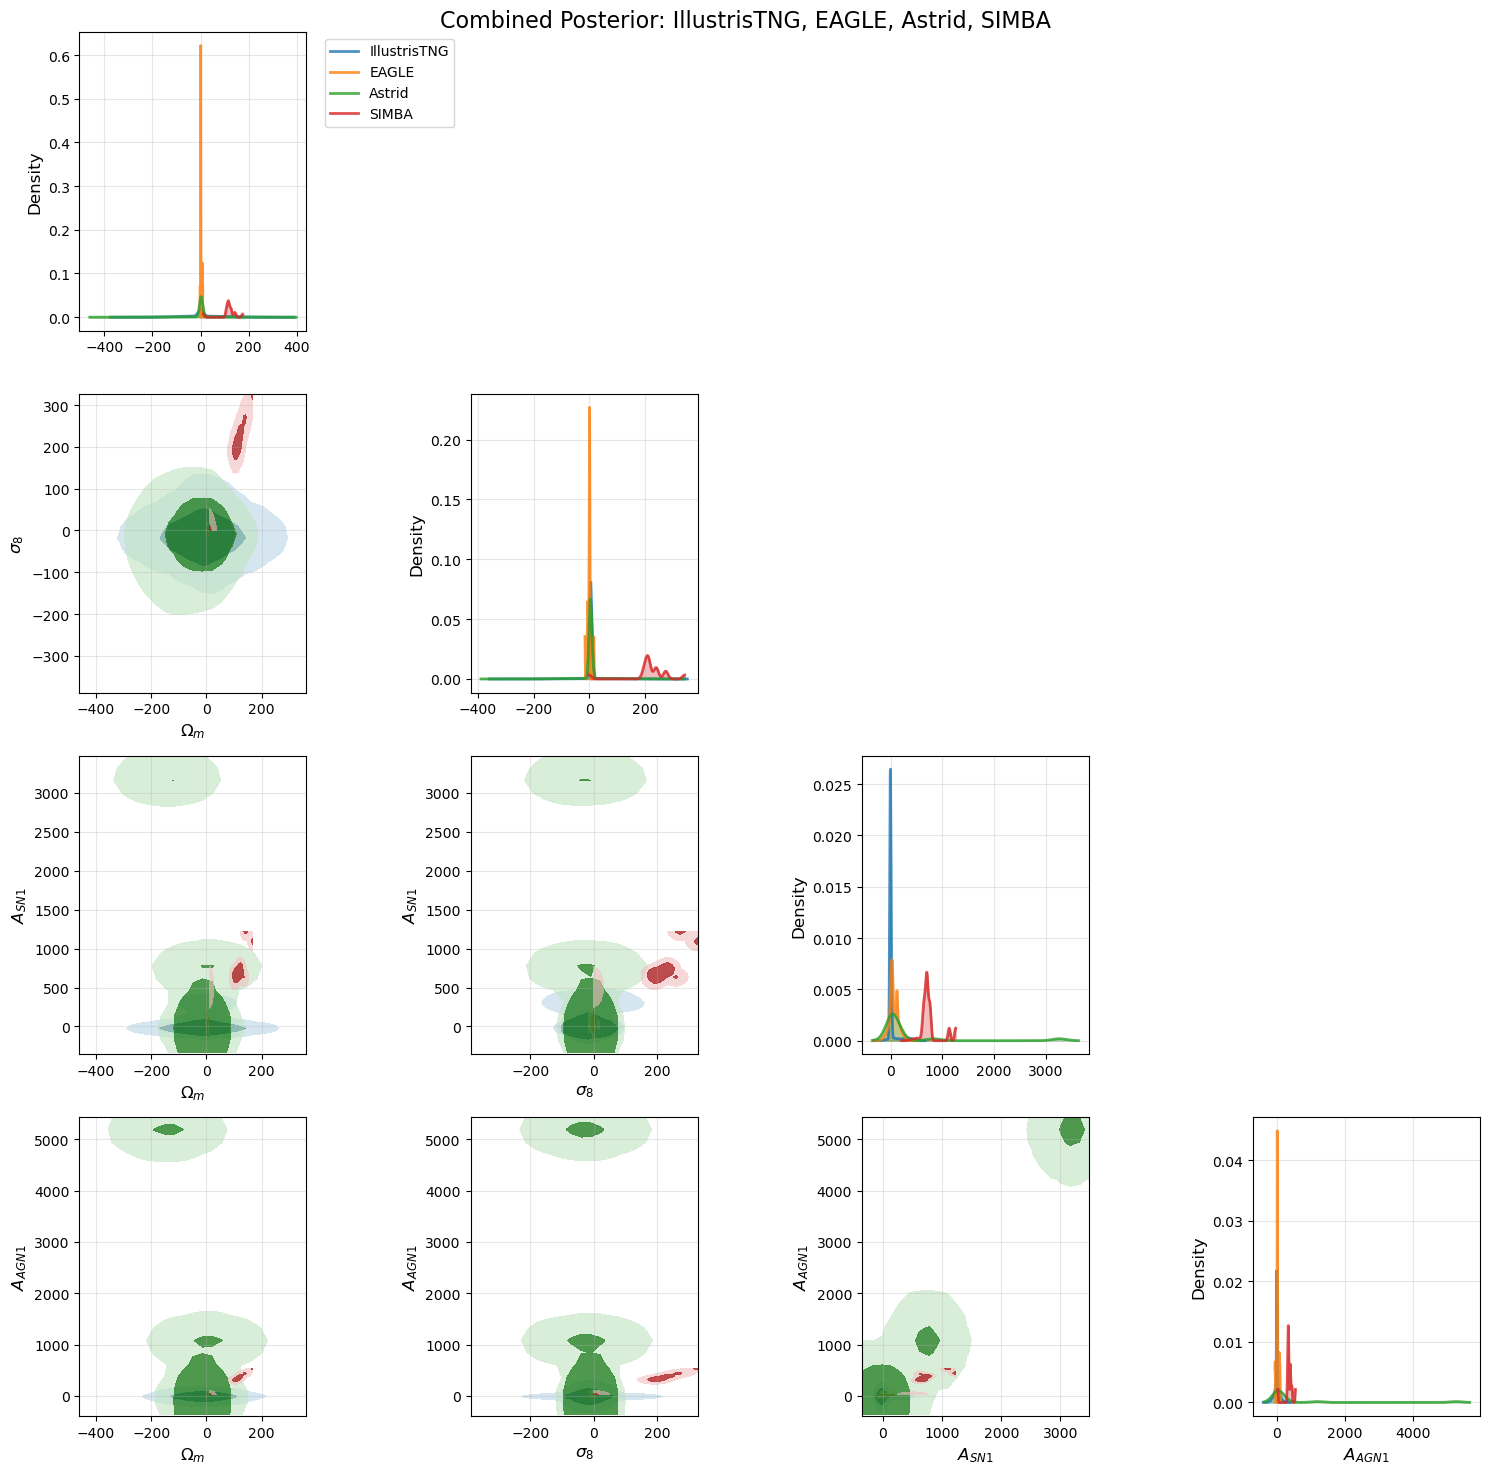

In [73]:

simulation_datasets = [
    {
        'features': TNG_features,
        'cosmo_params': TNG_cosmo_params, 
        'astro_params': TNG_astro_params,
        'name': 'IllustrisTNG',
        'color': '#1f77b4'
    },
    {
        'features': EAGLE_features,
        'cosmo_params': EAGLE_cosmo_params,
        'astro_params': EAGLE_astro_params, 
        'name': 'EAGLE',
        'color': '#ff7f0e'
    },
    {
        'features': Astrid_features,
        'cosmo_params': Astrid_cosmo_params,
        'astro_params': Astrid_astro_params,
        'name': 'Astrid', 
        'color': '#2ca02c'
    },
    {
        'features': SIMBA_features,
        'cosmo_params': SIMBA_cosmo_params,
        'astro_params': SIMBA_astro_params,
        'name': 'SIMBA',
        'color': '#d62728'
    }
]

# Run the analysis
models_data, fig, all_samples = run_multi_simulation_analysis(
    simulation_datasets, 
    param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$']
)


<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_338873/2082473625.py:2: SyntaxWarning: invalid escape sequence '\O'
  models_data, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'], n_points_per_model=2
/tmp/ipykernel_338873/2082473625.py:2: SyntaxWarning: invalid escape sequence '\s'
  models_data, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'], n_points_per_model=2


Creating combined corner plot for 4 simulation models...
Sampling from IllustrisTNG...
Sampling from EAGLE...
Sampling from Astrid...
Sampling from SIMBA...

Summary:
IllustrisTNG: 6000 samples from 2 test points
EAGLE: 6000 samples from 2 test points
Astrid: 6000 samples from 2 test points
SIMBA: 6000 samples from 2 test points


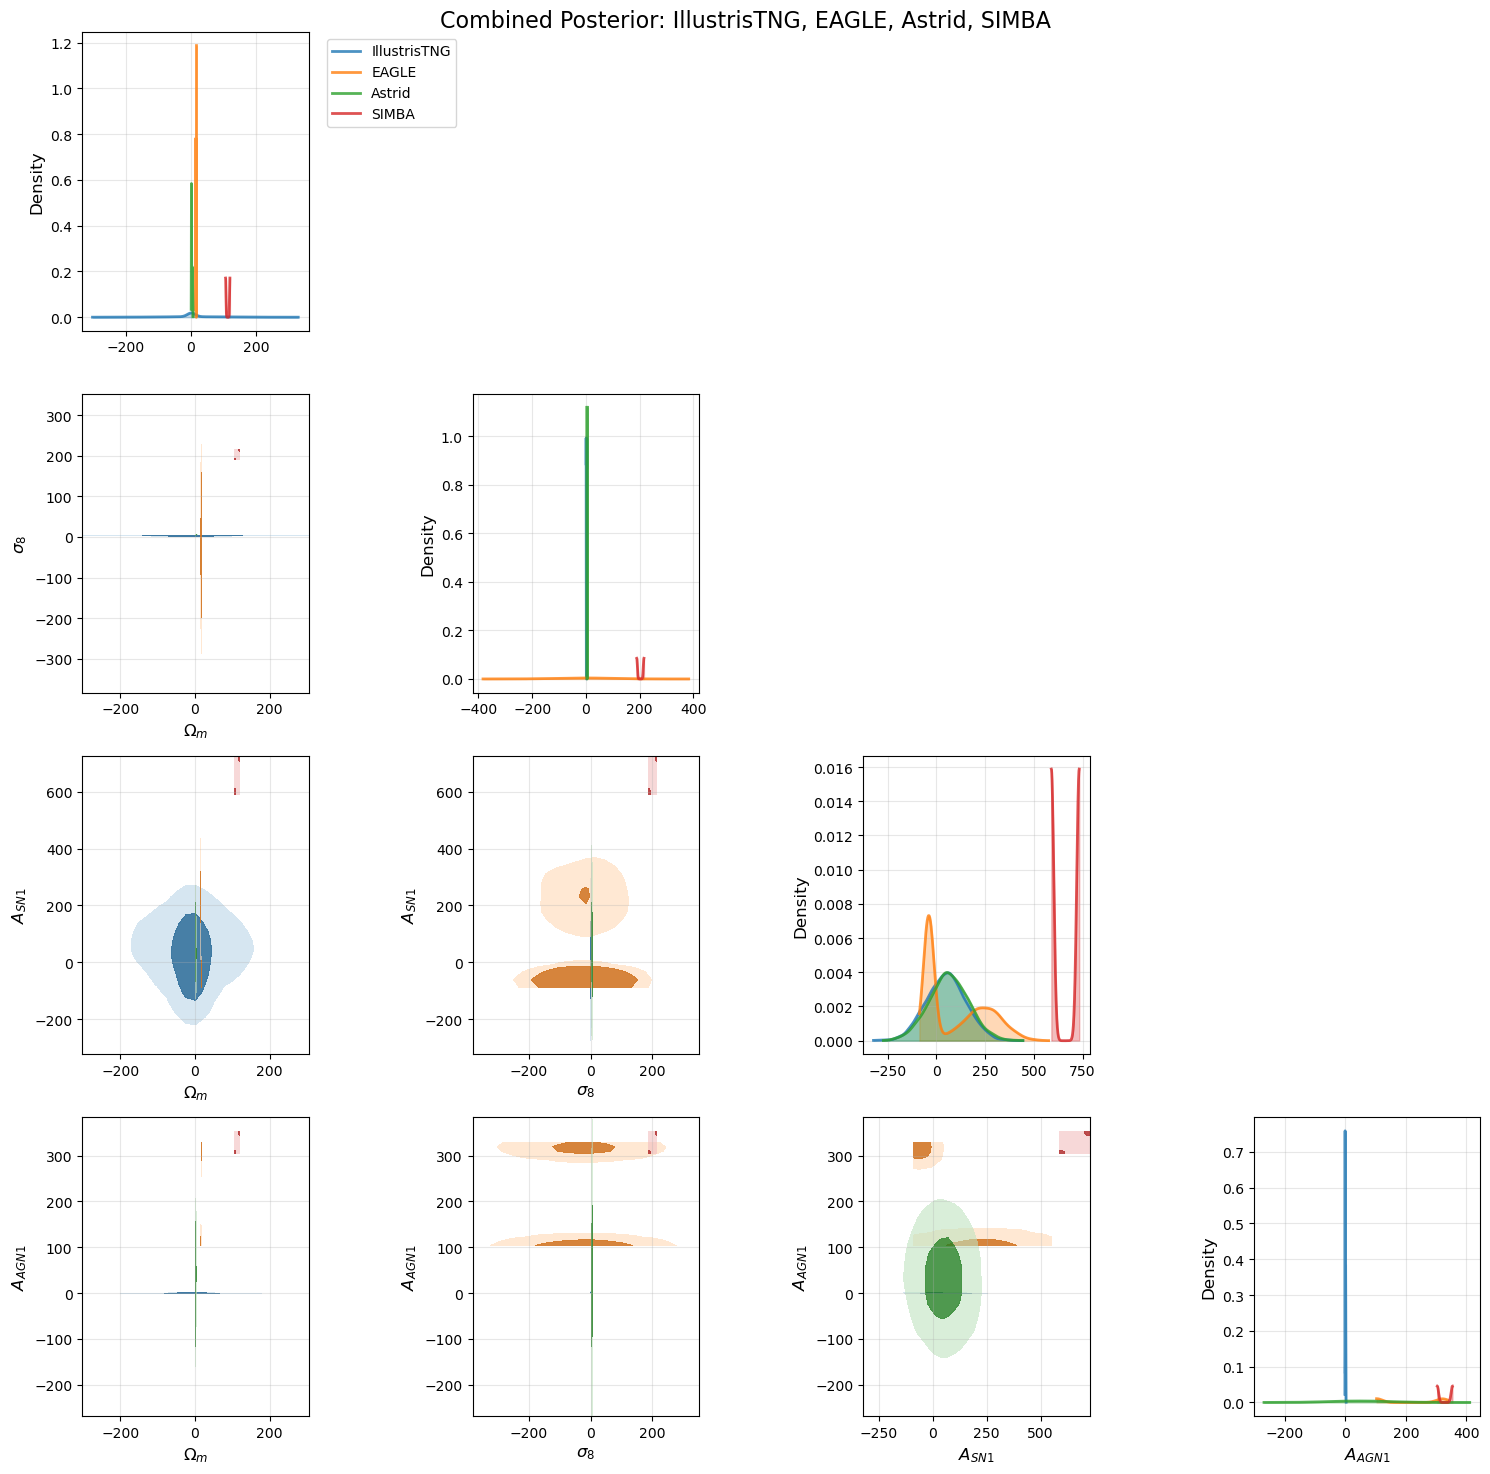

In [77]:
fig, axes, all_samples = create_multi_simulation_corner_plot(
    models_data, param_names=['$\Omega_m$', '$\sigma_8$', '$A_{SN1}$', '$A_{AGN1}$'], n_points_per_model=2
)

plt.show()

In [82]:
np.asarray(TNG_cosmo_params)[:,1].min()

np.float64(0.309)